# **Logistic Regression (Loan**
#**Approval Prediction) Assignment**

**Q1. Data Loading & Understanding**

**a) Load the dataset into Python.**

**b) Display the first 5 rows.**

**c) Check the shape of the dataset.**

**d) Display the data types of each column.**




In [10]:

import pandas as pd

# (a) Load the dataset
df = pd.read_excel("loan_approval.xlsx")

# (b) display the first 5 row
print("display 5 rows", df.head())

# (c) shape
print("shap of the dataset",df.shape)

# (d) data type
print("data type",df.dtypes)


display 5 rows               name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  
shap of the dataset (2000, 8)
data type name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


**Q2. Data Cleaning**

**a) Check for missing values in the dataset.**

**b) Handle missing values appropriately.**

**c) Identify categorical columns present in the dataset.**

In [13]:
# Check for missing values
print('Check for missing values',df.isnull().sum())

# Handle missing values
df['income'].fillna(df['income'].median())

#  Identify categorical columns present in the dataset.
categorical_cols = df.select_dtypes(include=['object']).columns
print("categorical columns present in the dataset:",categorical_cols)



Check for missing values name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64
categorical columns present in the dataset: Index(['name', 'city'], dtype='object')


**Q3. Exploratory Data Analysis (EDA)**

**a) Plot the distribution of the target variable.**

**b) Analyze the relationship between one numerical feature and the target variable.**

**c) Analyze the relationship between Years of Employment and the target variable.**

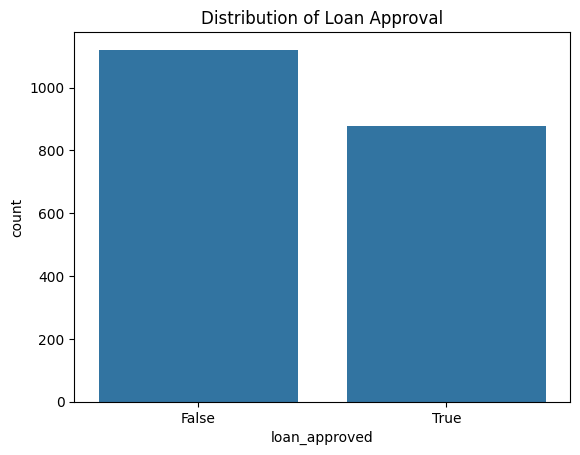

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of target variable
sns.countplot(x='loan_approved', data=df)
plt.title("Distribution of Loan Approval")
plt.show()


**(b) Analyze the relationship between one numerical feature and the target variable.**

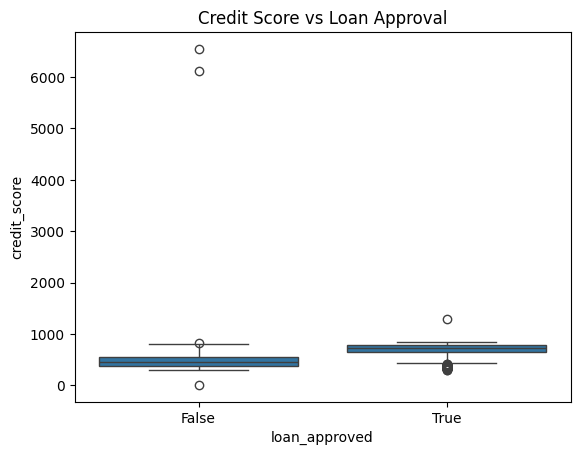

loan_approved
False    482.107939
True     704.403868
Name: credit_score, dtype: float64


In [15]:
sns.boxplot(x='loan_approved', y='credit_score', data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

# Alternatively, group means
print(df.groupby('loan_approved')['credit_score'].mean())


**(c) Analyze the relationship between Years of Employment and the target variable.**

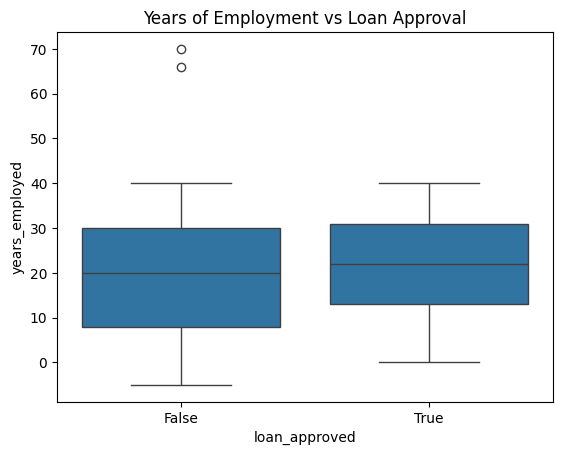

loan_approved
False    19.425513
True     21.829352
Name: years_employed, dtype: float64


In [16]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title("Years of Employment vs Loan Approval")
plt.show()

# Group statistics
print(df.groupby('loan_approved')['years_employed'].mean())


**Q4. Outlier Detection and Treatment**

**(a) Detect outliers in numerical columns using the IQR method.**


In [17]:
# Detect outliers using IQR
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")


income: 0 outliers
credit_score: 3 outliers
loan_amount: 0 outliers
years_employed: 2 outliers
points: 0 outliers


**(b) Treat outliers using capping techniques**

In [21]:
# Outlier treatment using capping without np
import numpy as np
for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping
    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

    # Print capped min and max values for verification
    print(f"{col} capped range: min={df[col].min()}, max={df[col].max()}")



income capped range: min=30053.0, max=149964.0
credit_score capped range: min=11.0, max=1140.5
loan_amount capped range: min=1022.0, max=49999.0
years_employed capped range: min=-5.0, max=62.5
points capped range: min=10.0, max=100.0


**Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
columns.**

In [22]:
# Convert target variable to numeric (if not already)
df['loan_approved'] = df['loan_approved'].astype(int)


# Drop unnecessary columns
df = df.drop(['name', 'city'], axis=1)

print(df.head())


     income  credit_score  loan_amount  years_employed  points  loan_approved
0  113810.0         389.0      39698.0            27.0    50.0              0
1   44592.0         729.0      15446.0            28.0    55.0              0
2   33278.0         584.0      11189.0            13.0    45.0              0
3  127196.0         344.0      48823.0            29.0    50.0              0
4   66048.0         496.0      47174.0             4.0    25.0              0


**Q6. Feature Selection and Data Splitting**

**a) Separate independent variables (X) and dependent variable (y).**

**b) Split the dataset into training and testing sets.**

In [23]:
# Separate features (X) and target (y)
X = df.drop('loan_approved', axis=1)   # independent variables
y = df['loan_approved']                # dependent variable

from sklearn.model_selection import train_test_split

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1600, 5)
Testing set shape: (400, 5)


**Q7. Apply feature scaling to the dataset using StandardScaler.**

In [24]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print shapes to confirm
print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled testing set shape:", X_test_scaled.shape)

# Optionally, check first 5 rows of scaled data
print("First 5 rows of scaled training data:\n", X_train_scaled[:5])


Scaled training set shape: (1600, 5)
Scaled testing set shape: (400, 5)
First 5 rows of scaled training data:
 [[-0.17342933  0.47850982  0.03478074 -1.14858773 -0.1017349 ]
 [-0.22960205  0.77983528 -1.22829888  1.3855275   1.25699495]
 [ 0.4646404  -0.56075553  0.36246017  1.46999801 -0.37348087]
 [-0.76117645  1.02581524 -0.84514756  1.3855275   1.25699495]
 [ 1.06164292  1.65306415 -1.23690902 -0.30388265  2.34397883]]


**Q8. Logistic Regression Model Building**

**a) Train a Logistic Regression model.**

**b) Predict the output for test data.**

In [25]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Model training complete.")

# Predict on test set
y_pred = log_reg.predict(X_test_scaled)

# Print first 10 predictions for verification
print("Predictions on test data:", y_pred[:10])


Model training complete.
Predictions on test data: [1 0 1 1 0 1 0 1 0 0]


**Q9. Model Evaluation – Confusion Matrix**

**a) Generate the confusion matrix.**

**b) Interpret the results.**

In [26]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[224   0]
 [  0 176]]


**Q10. Model Evaluation – ROC Curve & AUC**

**a) Plot the ROC curve.**



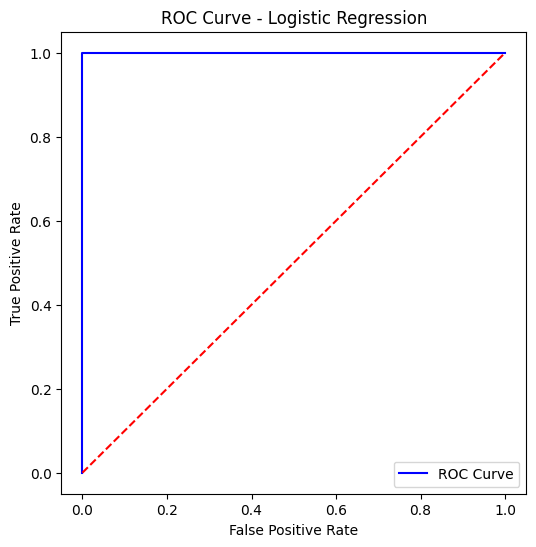

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


**b) Calculate the AUC score.**

In [28]:
# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred_prob)
print("AUC Score:", auc_score)


AUC Score: 1.0
